In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

/var/folders/hs/1t60kyd15t31kkd07pldztrr0000gn/T/ipykernel_7650/3777615979.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [3]:
import pandas as pd
import networkx as nx
from geopy.distance import geodesic
import numpy as np
from math import radians, cos, sin, sqrt, atan2
import matplotlib.pyplot as plt
import random
from haversine import haversine

## Project 2. Due by Thursday, February 27. ##

For this project we will use the **New York Electric Grid (NYISO) Data**.

Throughout, we will compute the length of a link as computed using the latitude and longitude of each node (termed 'bus' in the data set).

1. Repeat one million times: take a randomly chosen pair of nodes A and B, and compute the length of a shortest path between them. You can use any library for this purpose. Plot a histogram showing the distribution of lengths.

2. Implement the algorithm for the minimum-cost node tour problem (i.e., the node inspection problem) on this data.  You only need to examine **one** pairing of the odd nodes. You only need to report on the **cost** of your tour, that is to say you do not need to implement the splicing operation.

3. Now repeat step 2, examining *random* pairings of the odd nodes.  Perform this step for at least 1000 pairings.  The TA/CA may ask to perform more.  Report on the best solution you find.

4. Extra credit (**only do this if 1-3 are 100% completed**).  Use the 'splicing' algorithm to actually compute the tour itself, for the best solution obtained in Step 3.


In [4]:
# Load data into Pandas Dataframes
branches = pd.read_csv("./NewYorkElectricGrid/nyisobranches.csv")
buses = pd.read_csv("./NewYorkElectricGrid/nyisobuses.csv", skiprows=1)

In [5]:
branches

,branch number,first bus number,second bus number
0,1,123,4232
1,2,187,3532
2,3,239,76466
3,4,338,8443
4,5,845,8079
...,...,...,...
2198,2199,77053,77054
2199,2200,77094,77095
2200,2201,77161,77162
2201,2202,77541,77542


In [6]:
buses

,Number,Name,Area Name,Latitude,Longitude,Status,# Neighbors (in service only),Nom kV,PU Volt,Volt (kV),...,Gen Min MW,Gen Max MW,Gen Min Mvar,Gen Max Mvar,Switched Shunts Mvar,Switched Shunts Nom Mvar,Max Mvar,Min Mvar,Area Num,Zone Num
0,123,J C McNeil,Vermont,44.492,-73.208,Connected,1,138.0,0.99773,137.686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35,1
1,187,9001043100,Connecticut,41.110,-73.457,Connected,1,138.0,0.99500,137.310,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
2,239,9001071000,Connecticut,41.172,-73.218,Connected,1,230.0,1.00859,231.975,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
3,338,9001245500,Connecticut,41.275,-73.516,Connected,1,138.0,0.95884,132.319,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
4,845,9011690300,Connecticut,41.293,-72.925,Connected,1,138.0,0.98595,136.062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1809,78955,42069110600,Pennsylvania,41.554,-75.509,Connected,1,230.0,0.99588,229.053,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29,1
1810,95339,PJM Proxy,Pennsylvania,42.251,-79.764,Connected,1,345.0,1.01738,350.997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29,1
1811,95340,Brentwood,New York,40.781,-73.246,Connected,1,138.0,0.99204,136.902,...,1.0,47.0,0.0,0.0,NaN,NaN,NaN,NaN,24,1
1812,95341,Bayswater Peaking Facility LLC,New York,40.610,-73.761,Connected,1,138.0,0.97215,134.157,...,26.0,60.5,0.0,0.0,NaN,NaN,NaN,NaN,24,1


In [7]:
buses.columns

Index(['Number', 'Name', 'Area Name', 'Latitude', 'Longitude', 'Status',
       '# Neighbors (in service only)', 'Nom kV', 'PU Volt', 'Volt (kV)',
       'Angle (Deg)', 'Load MVA', 'Load MW', 'Load Mvar', 'Gen MW', 'Gen Mvar',
       'Gen Min MW', 'Gen Max MW', 'Gen Min Mvar', 'Gen Max Mvar',
       'Switched Shunts Mvar', 'Switched Shunts Nom Mvar', 'Max Mvar',
       'Min Mvar', 'Area Num', 'Zone Num'],
      dtype='object')

In [8]:
branches = branches.rename(columns={
    ' first bus number' : 'first_bus_number',
    ' second bus number' : 'second_bus_number',
    'branch number' : 'branch_number',
})

In [9]:
branches.columns

Index(['branch_number', 'first_bus_number', 'second_bus_number'], dtype='object')

In [10]:
G = nx.Graph()

for index, row in buses.iterrows():
    bus_id = int(row['Number'])
    G.add_node(bus_id, latitude = row['Latitude'], longitude = row['Longitude'])


for index, row in branches.iterrows():
    bus1, bus2 = int(row['first_bus_number']), int(row['second_bus_number'])
    if bus1 in G.nodes and bus2 in G.nodes:
        p1 = G.nodes[bus1]['latitude'], G.nodes[bus1]['longitude']
        p2 = G.nodes[bus2]['latitude'], G.nodes[bus2]['longitude']
        distance = haversine(p1, p2)
        G.add_edge(bus1, bus2, weight=distance)


1. Repeat one million times: take a randomly chosen pair of nodes A and B, and compute the length of a shortest path between them. You can use any library for this purpose. Plot a histogram showing the distribution of lengths.

In [11]:
# Our seed is Louren's Bday
random.seed(223)

shortest_path_length = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
shortest_paths = []

for _ in range(1000000):
    node_a, node_b = np.random.choice(list(G.nodes), size =2)
    path_length = shortest_path_length[node_a][node_b]
    shortest_paths.append(path_length)

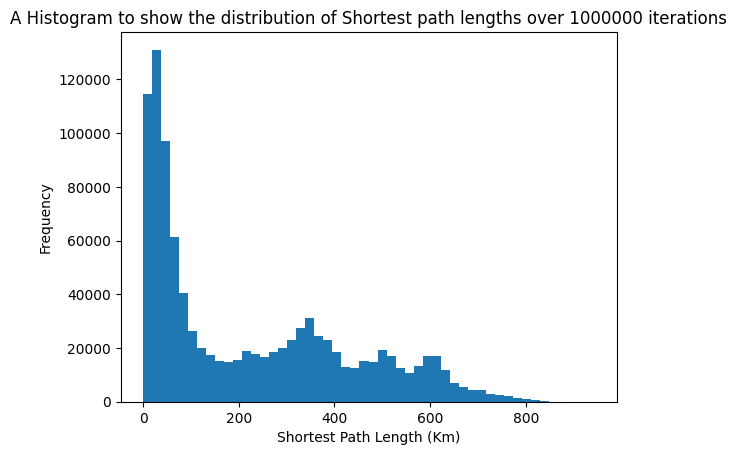

In [12]:
plt.figure()
plt.hist(shortest_paths, bins = 50)
plt.xlabel("Shortest Path Length (Km)")
plt.ylabel("Frequency")
plt.title("A Histogram to show the distribution of Shortest path lengths over 1000000 iterations")
plt.show()

2. Implement the algorithm for the minimum-cost node tour problem (i.e., the node inspection problem) on this data.  You only need to examine **one** pairing of the odd nodes. You only need to report on the **cost** of your tour, that is to say you do not need to implement the splicing operation.

In [13]:
import networkx as nx
from itertools import combinations

# Find MST and odd-degree nodes
mst = nx.minimum_spanning_tree(G)
odd_degree_nodes = [node for node, degree in mst.degree() if degree % 2 == 1]

# Compute all-pairs shortest paths for odd-degree nodes
shortest_paths = {}
for u, v in combinations(odd_degree_nodes, 2):
    try:
        shortest_paths[(u, v)] = nx.shortest_path_length(G, source=u, target=v, weight="weight")
    except nx.NetworkXNoPath:
        continue

# Create a new graph where edges represent shortest paths between odd-degree nodes
odd_graph = nx.Graph()
for (u, v), cost in shortest_paths.items():
    odd_graph.add_edge(u, v, weight=cost)

# Find optimal pairing using minimum weight matching
matching = nx.algorithms.matching.min_weight_matching(odd_graph, weight="weight")

# Compute total cost
mst_length = mst.size(weight="weight")
matching_cost = sum(shortest_paths.get((u, v), shortest_paths.get((v, u))) for u, v in matching)
total_cost = mst_length + matching_cost

print(f"Minimum-cost node tour: {total_cost:.2f} km")


Minimum-cost node tour: 12450.13 km


3. Now repeat step 2, examining *random* pairings of the odd nodes.  Perform this step for at least 1000 pairings.  The TA/CA may ask to perform more.  Report on the best solution you find

In [14]:
def random_pairing(odd_nodes):
    random.shuffle(odd_nodes)
    return list(zip(odd_nodes[::2], odd_nodes[1::2]))

best_cost = float('inf')
best_matching = None

for _ in range(1000):
    random_pairs = random_pairing(odd_degree_nodes[:])
    
    path_costs = []
    for node_a, node_b in random_pairs:
        try:
            cost = nx.shortest_path_length(G, node_a, node_b, weight="weight")
            path_costs.append(cost)
        except nx.NetworkXNoPath:
            path_costs.append(float('inf'))
    
    total_cost = G.size(weight="weight") + sum(path_costs)

    if total_cost < best_cost:
        best_cost = total_cost
        best_matching = random_pairs

print(f"Best minimum-cost node tour found: {best_cost:.2f} km")


Best minimum-cost node tour found: 74398.81 km
